# Introduction

This notebook analyzes the 2015 US domestic flight network as a graph. Airports are modeled as nodes, flight events as flight nodes, and route-level relationships are used to study connectivity, delay propagation, and structural fragility.

The goal is to answer two research questions:
1. Which airports are most critical for delay propagation and connectivity betheen different operational clusters?
2. Which routes and network structures act as bridges between operational clusters?
3. How does the network behave when critical inter-community links are removed?


The analysis combines preprocessing, graph construction in Neo4j, exploratory graph analysis, community detection, centrality measures, and shortest-path analysis.

In [1]:
%pip install -U pip scipy kagglehub pandas matplotlib geopandas scikit-learn umap-learn neo4j networkx seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import libs

import pandas as pd
import numpy as np
import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import geopandas as gpd
import seaborn as sns
from scipy.stats import entropy
from sklearn.preprocessing import OneHotEncoder
import os
from statlib.domain_tools import load_datasets
from copy import copy, deepcopy
from statlib.representative_sample import find_most_representative_sample, generic_df_into_numeric_and_rollback
import tempfile
from pathlib import Path
import requests
import zipfile
import networkx as nx
from scipy.stats import ks_2samp
from networkx.algorithms.community import greedy_modularity_communities, girvan_newman, modularity
from networkx.algorithms.community import modularity, louvain_communities
from sklearn.preprocessing import  StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform


In [3]:
# Datasets loading
ds_name_list = ["airlines.csv","airports.csv","flights.csv"]
df_full = load_datasets(ds_name_list, omogenize=True)

/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv_310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading airlines.csv...
Loading airports.csv...
Loading flights.csv...


/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv_310/lib/python3.10/site-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


In [4]:

# split data type

flights_column_type = {
    # numeric
    "YEAR": "Val",
    "MONTH": "Val",
    "DAY": "Val",
    "DAY_OF_WEEK": "Val",
    "FLIGHT_NUMBER": "Val",
    "SCHEDULED_DEPARTURE": "Val",
    "DEPARTURE_TIME": "Val",
    "DEPARTURE_DELAY": "Val",
    "TAXI_OUT": "Val",
    "WHEELS_OFF": "Val",
    "SCHEDULED_TIME": "Val",
    "ELAPSED_TIME": "Val",
    "AIR_TIME": "Val",
    "DISTANCE": "Val",
    "WHEELS_ON": "Val",
    "TAXI_IN": "Val",
    "SCHEDULED_ARRIVAL": "Val",
    # number
    "CANCELLATION_REASON": "Str",
    "AIRLINE": "Str",
    "TAIL_NUMBER": "Str",
    "ORIGIN_AIRPORT": "Str",
    "DESTINATION_AIRPORT": "Str",
}

In [5]:
# Set global parameters 
FAST_SAMPLE = True
GLOBAL_SEED = 667
SAMPLE_SIZE = 5000
CACHE_FILE = "sample_cache"

In [6]:

# make a copy for future analisys
dfs_kv = copy(df_full)
if FAST_SAMPLE:
    for k in dfs_kv.keys():
        filename=CACHE_FILE+k+'.csv'
        filename_pkl=CACHE_FILE+k+'.pkl'
        if len(df_full[k]) > SAMPLE_SIZE:
            if os.path.exists(filename):
                dfs_kv[k] = pd.read_csv(filename)
            else:
                try:
                    dfs_kv[k] = pd.read_pickle(filename_pkl)
                    dfs_kv[k].to_csv(filename, index=False)
                except :
                    dfs_kv[k] = find_most_representative_sample(dfs_kv[k] , flights_column_type, GLOBAL_SEED , SAMPLE_SIZE, n_trials=35  )
                    dfs_kv[k].to_pickle(filename_pkl)

# Dataset description

- flights.csv
    - YEAR, MONTH, DAY, DAY_OF_WEEK: dates of the flight
    - AIRLINE: identify a unique airline
    - ORIGIN_AIRPORT_IATA_CODE and DESTINATION_AIRPORT_IATA_CODE: code attributed by IATA to identify the airports
    - SCHEDULED_DEPARTURE and SCHEDULED_ARRIVAL : scheduled times of take-off and landing
    - DEPARTURE_TIME and ARRIVAL_TIME: real times at which take-off and landing took place
    - DEPARTURE_DELAY and ARRIVAL_DELAY: difference (in minutes) between planned and real times
    - DISTANCE: distance (in miles)
    - CANCELLED: 1 if is deleted
    - CANCELLATION_REASON: if is cancelled, the reason code
    - SCHEDULED_TIME: estimated flight time
    - ELAPSED_TIME: effective flight time
    - AIR_TIME: effective on-air time
    - TAXI_OUT: time from the gate to lift-off
    - WHEELS_OFF: effective moment of lift-off
    - WHEELS_ON: effective moment of landing
    - DIVERTED: some reason flight get different landing
- airports.csv
    - AIRPORTS_IATA_CODE: unique identifier code
    - CITY STATE COUNTRY LATITUDE LONGITUDE : geo referencies
- airlines.csv
    . naming referencies (we can ignore it for data analisys)


In [7]:
# dataset preview
for df in dfs_kv.values():
    display(df.head())

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,6,28,7,DL,2241,N3762Y,ATL,ORD,2048,...,2147.0,-10.0,False,False,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,7,24,5,B6,50,N316JB,SAV,BOS,1415,...,1629.0,-4.0,False,False,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,8,8,6,OO,6354,N908SW,DEN,FCA,1414,...,1607.0,-21.0,False,False,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,12,23,3,B6,52,N637JB,MCO,BOS,805,...,1100.0,7.0,False,False,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,11,8,7,UA,898,N835UA,IAH,MSY,2127,...,2225.0,-15.0,False,False,NaN,NaN,NaN,NaN,NaN,NaN


# Taking a look on Airport geographical displacement

In [8]:
# plot geo data


tmpdir = Path(tempfile.mkdtemp(prefix="us_maps_"))
url = "https://www2.census.gov/geo/tiger/GENZ2025/shp/cb_2025_us_state_5m.zip"
r = requests.get(url, stream=True)
r.raise_for_status()
zip_path = tmpdir / "us_states.zip"
with open(zip_path, "wb") as f:
    for chunk in r.iter_content(chunk_size=8192):
        f.write(chunk)

In [9]:
# write geo shapefile

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(tmpdir)


In [10]:
# read geo shapefile and airports data, creating a geodataframe for both

shp_files = list(tmpdir.glob("*.shp"))
states_gdf = gpd.read_file(shp_files[0])
airports_gdf = gpd.GeoDataFrame(
    dfs_kv["airports.csv"],
    geometry=gpd.points_from_xy(
        dfs_kv["airports.csv"]["LONGITUDE"], 
        dfs_kv["airports.csv"]["LATITUDE"]
    ),
    crs="EPSG:4326"  # WGS84
)


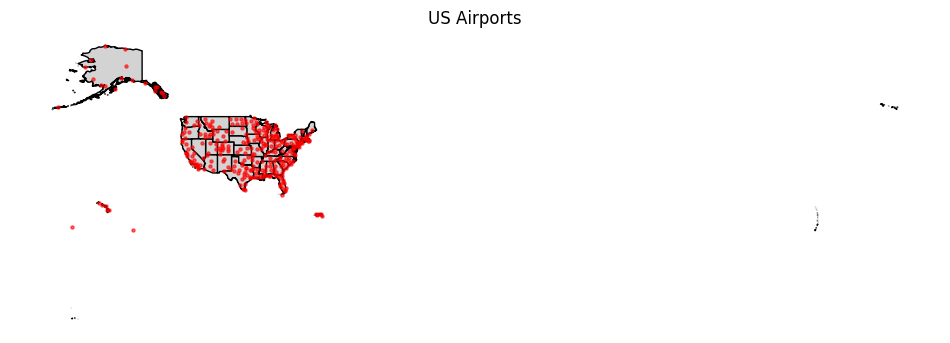

In [11]:
# Plot: states + airports
fig, ax = plt.subplots(figsize=(12, 8))

# Plot states
states_gdf.plot(ax=ax, color="lightgray", edgecolor="black")

# Plot airports
airports_gdf.plot(ax=ax, color="red", markersize=5, alpha=0.6)

ax.set_title("US Airports")
ax.set_axis_off()
plt.show()

In [12]:
%reload_ext autoreload
# Get latest preprocessed data
from statlib.domain_tools import build_df_final_clean_from_airports_raw_spark

df_final_clean, neo_airports, neo_flights = build_df_final_clean_from_airports_raw_spark(dfs_kv["flights.csv"], dfs_kv["airports.csv"])



Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/06 17:51:18 WARN Utils: Your hostname, pvenas10, resolves to a loopback address: 127.0.1.1; using 10.0.0.100 instead (on interface vmbr0)
26/09/06 17:51:18 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/06 17:51:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Converted pandas DataFrames to PySpark DataFrames. Proceeding with Spark transformations.


26/09/06 17:51:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/06 17:51:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/06 17:51:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/06 17:51:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/06 17:51:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/06 17:51:46 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/06 1

In [13]:
# Quick preview airports
display(neo_airports.head())

,IATA,CITY,STATE,LATITUDE,LONGITUDE
0,ABE,Allentown,PA,40.65236,-75.44040
1,ABI,Abilene,TX,32.41132,-99.68190
2,ABQ,Albuquerque,NM,35.04022,-106.60919
3,ABR,Aberdeen,SD,45.44906,-98.42183
4,ACK,Nantucket,MA,41.25305,-70.06018


In [14]:
# Quick preview flights
display(neo_flights.head())

,FLIGHT_ID,DATETIME,AIRLINE_CODE,ORIGIN_IATA,DEST_IATA,DISTANCE,TOTAL_DELAY,CANCELLATION_REASON
0,1,2015-06-28,DL,ATL,ORD,606,0.5,None
1,2,2015-07-24,B6,SAV,BOS,901,0.0,None
2,3,2015-08-08,OO,DEN,FCA,752,0.0,None
3,4,2015-12-23,B6,MCO,BOS,1121,10.5,None
4,5,2015-11-08,UA,IAH,MSY,305,0.0,None


In [15]:
# null value permitted, arrivals
print("permitted null values (not cancelled flights)", neo_flights["CANCELLATION_REASON"])

permitted null values (not cancelled flights) 0       None
1       None
2       None
3       None
4       None
        ... 
4517    None
4518    None
4519    None
4520    None
4521    None
Name: CANCELLATION_REASON, Length: 4522, dtype: object


In [16]:
# dataset len
print("Rows count:", len(df_final_clean))

Rows count: 4522


# End of preprocessing

# Connect and delete GDB
For having an idempotent effect

In [17]:
# Open the Neo4j driver and prepare the query helper functions.
import pandas as pd
from redis import Redis

try:
  FALKORDB_HOST = "10.0.0.79"  # o l'IP del tuo server FalkorDB
  FALKORDB_PORT = 6379
  GRAPH_NAME = "flight_network"
  DATABASE = "falkordb"
  driver = Redis(
      host=FALKORDB_HOST,
      port=FALKORDB_PORT,
      decode_responses=True,
      socket_connect_timeout=10,
      socket_timeout=30
  )
  driver.ping()

except Exception as e:
  
  print(f"Redis: FalkorDB: {FALKORDB_HOST}:{FALKORDB_PORT}")
  print("Please check your connection settings and ensure the FalkorDB server is running.")
  raise ConnectionError("Failed to connect to FalkorDB. Please check your connection settings and ensure the FalkorDB server is running.")

print("Connected to FalkorDB")

Connected to FalkorDB


In [18]:
import pandas as pd


def _graph_query_to_df(graph_result):
    if not isinstance(graph_result, list) or len(graph_result) < 2:
        return pd.DataFrame(graph_result)

    header, rows = graph_result[0], graph_result[1]

    try:
        columns = [
            col[1] if isinstance(col, (list, tuple)) and len(col) > 1 else str(col)
            for col in header
        ]
    except Exception:
        columns = None

    if columns:
        return pd.DataFrame(rows, columns=columns)
    return pd.DataFrame(rows)


In [19]:
# delete all graphs to avoid conflicts
graphs = driver.execute_command("GRAPH.LIST")
print(graphs)


['falkordb']


In [20]:
# Delete the existing graph (all nodes and relationships)
try:
    driver.execute_command("GRAPH.QUERY", DATABASE, "MATCH (n) DETACH DELETE n")
except Exception:
    print("Error deleting existing graph. It may not exist yet.")

try:
    for graph_name in graphs:
        driver.execute_command("GRAPH.DELETE", graph_name)
        print("Dropped graph:", graph_name)
except Exception:
    print("Error deleting some graphs.")


Dropped graph: falkordb


In [21]:
graphs = driver.execute_command("GRAPH.LIST")
graphs


[]

In [22]:
# FalkorDB constraints and indexes creation

constraint = [
    "CREATE CONSTRAINT ON (a:Airport) ASSERT a.iata IS UNIQUE;",
    "CREATE CONSTRAINT ON (al:Airline) ASSERT al.code IS UNIQUE;",
    "CREATE CONSTRAINT ON (f:Flight) ASSERT f.flight_id IS UNIQUE;",
    "CREATE CONSTRAINT ON (r:Route) ASSERT r.route_id IS UNIQUE;",

    "CREATE INDEX ON :Airport(city);",
    "CREATE INDEX ON :Airport(state);",
    "CREATE INDEX ON :Flight(date);",
    "CREATE INDEX ON :Route(source_iata);",
    "CREATE INDEX ON :Route(dest_iata);",
    "CREATE INDEX ON :Route(flight_count);",
]

for i in constraint:
    try:
        driver.execute_command("GRAPH.QUERY", DATABASE, i)
    except Exception as e:
        print(f"Constraint/index skipped: {e}")

print("Constraints created.")


Constraint/index skipped: Invalid constraint command use the GRAPH.CONSTRAINT command instead
Constraint/index skipped: Invalid constraint command use the GRAPH.CONSTRAINT command instead
Constraint/index skipped: Invalid constraint command use the GRAPH.CONSTRAINT command instead
Constraint/index skipped: Invalid constraint command use the GRAPH.CONSTRAINT command instead
Constraints created.


# Airports insertion

In [23]:
import pandas as pd
import math


def cypher_value(value):
    if value is None:
        return "null"

    if isinstance(value, bool):
        return "true" if value else "false"

    if isinstance(value, (int, float)):
        if isinstance(value, float) and math.isnan(value):
            return "null"
        return str(value)

    return '"' + str(value).replace("\\", "\\\\").replace('"', '\\"') + '"'

#  pandas or Spark before insert
if hasattr(neo_airports, "toPandas") and callable(getattr(neo_airports, "toPandas")):
    airports_pdf = neo_airports.toPandas()
else:
    airports_pdf = neo_airports.copy()

airports_pdf = airports_pdf.where(pd.notnull(airports_pdf), None)

rows_airports = airports_pdf.to_dict(orient="records")

rows_cypher = ", ".join(
    "{" + ", ".join(
        f"{key}: {cypher_value(value)}"
        for key, value in row.items()
    ) + "}"
    for row in rows_airports
)

query = f"""
UNWIND [{rows_cypher}] AS row
MERGE (a:Airport {{iata: row.IATA}})
SET a.city = row.CITY,
    a.state = row.STATE,
    a.latitude = row.LATITUDE,
    a.longitude = row.LONGITUDE
"""

driver.execute_command(
    "GRAPH.QUERY",
    DATABASE,
    query
)

print(f"Inserted airports: {len(rows_airports)}")

Inserted airports: 277


# Flight insertion

In [24]:
#  pandas or Spark before insert
if hasattr(neo_flights, "toPandas") and callable(getattr(neo_flights, "toPandas")):
    flights_pdf = neo_flights.toPandas()
else:
    flights_pdf = neo_flights.copy()

rows_flights = flights_pdf.where(pd.notnull(flights_pdf), None).copy()
rows_flights["DATETIME"] = rows_flights["DATETIME"].astype(str)
rows_flights = rows_flights.to_dict("records")


flights_cypher = ", ".join(
    "{" + ", ".join(
        f"{key}: {cypher_value(value)}"
        for key, value in row.items()
    ) + "}"
    for row in rows_flights
)


driver.execute_command(
    "GRAPH.QUERY",
    DATABASE,
    f"""
    UNWIND [{flights_cypher}] AS row
    MATCH (o:Airport {{iata: row.ORIGIN_IATA}})
    MATCH (d:Airport {{iata: row.DEST_IATA}})
    MERGE (al:Airline {{code: row.AIRLINE_CODE}})
    MERGE (f:Flight {{flight_id: row.FLIGHT_ID}})

    MERGE (r:Route {{route_id: row.ORIGIN_IATA + ' → ' + row.DEST_IATA}})
        ON CREATE SET
            r.source_iata = row.ORIGIN_IATA,
            r.dest_iata = row.DEST_IATA,
            r.flight_count = 1,
            r.distance = row.DISTANCE,
            r.sum_of_delay = coalesce(row.TOTAL_DELAY, 0),
            r.last_time_used = date(row.DATETIME)
        ON MATCH SET
            r.flight_count = r.flight_count + 1,
            r.sum_of_delay = r.sum_of_delay + coalesce(row.TOTAL_DELAY, 0),
            r.last_time_used = date(row.DATETIME),
            r.distance = coalesce(r.distance, row.DISTANCE)

    SET f.date = date(row.DATETIME),
        f.distance = row.DISTANCE,
        f.total_delay = row.TOTAL_DELAY,
        f.cancellation_reason = CASE WHEN row.CANCELLATION_REASON = "" THEN null ELSE row.CANCELLATION_REASON END
    MERGE (al)-[op:OPERATED]->(f)
    ON CREATE SET op.cancelled_count = CASE WHEN coalesce(row.CANCELLED, false) THEN 1 ELSE 0 END
    ON MATCH SET op.cancelled_count = op.cancelled_count + (CASE WHEN coalesce(row.CANCELLED, false) THEN 1 ELSE 0 END)
    MERGE (f)-[rf:FROM]->(o)
    ON CREATE SET rf.starting_count = 1
    ON MATCH SET rf.starting_count = rf.starting_count + 1
    MERGE (f)-[rt:TO]->(d)
    ON CREATE SET rt.arrival_count = 1
    ON MATCH SET rt.arrival_count = rt.arrival_count + 1
    """
)

after_result = driver.execute_command("GRAPH.QUERY", DATABASE, "MATCH (f:Flight) RETURN count(f) AS n")
after_df = _graph_query_to_df(after_result)
after_count = int(after_df.iloc[0]["n"]) if not after_df.empty else 0
print(f"Flights after insert   : {after_count}")


Flights after insert   : 4522


# Now we have populated the neo4j graph 



# EDA - FASE 1


## Graph cardinality overview 

In [25]:
# Quick node label overview to confirm the expected distribution of node types.
result = driver.execute_command("GRAPH.QUERY", DATABASE, """
MATCH (n)
UNWIND labels(n) AS lbl
RETURN lbl AS node_label, count(*) AS count
ORDER BY count DESC
""")
result_df = _graph_query_to_df(result)
result_df

,node_label,count
0,Flight,4522
1,Route,2164
2,Airport,277
3,Airline,14


### Relationship Types

| Relationship |  Properties |
|--------------|-----------|
| `(:Flight)-[:FROM]->(:Airport)`  | `starting_count` | 
| `(:Flight)-[:TO]->(:Airport)`  | `arrival_count` | 
| `(:Airport)-[:ROUTE_TO]->(:Airport)`  | `flights`,  `total_delay` | 

# Relationship building


## Rank analisys

In [26]:
# Route aggregation: create/update ROUTE_TO relationships with aggregated flight counts and average delays.
route_build = _graph_query_to_df(driver.execute_command("GRAPH.QUERY", DATABASE, """
MATCH (f:Flight)-[:FROM]->(o:Airport)
MATCH (f)-[:TO]->(d:Airport)
WITH o, d,
     count(f) AS flights,
     sum(coalesce(f.total_delay, 0.0)) AS total_delay,
     avg(coalesce(f.total_delay, 0.0)) AS avg_delay,
     avg(f.distance) AS avg_distance
MERGE (o)-[r:ROUTE_TO]->(d)
SET r.flights = flights,
    r.total_delay = total_delay,
    r.avg_delay = avg_delay,
    r.avg_distance = avg_distance
RETURN count(r) AS route_relationships
"""))

print("ROUTE_TO relationships created")
display(route_build)

ROUTE_TO relationships created


,route_relationships
0,2164


# Route distribution

In [27]:
# check route distribution
_graph_query_to_df(driver.execute_command("GRAPH.QUERY", DATABASE, """
MATCH (f:Flight)-[:FROM]->(o:Airport)
MATCH (f)-[:TO]->(d:Airport)
WITH o, d, count(f) AS flights_per_route
RETURN flights_per_route, count(*) AS number_of_routes
ORDER BY flights_per_route DESC
"""))

,flights_per_route,number_of_routes
0,14,1
1,13,2
2,12,2
3,11,1
4,10,4
5,9,6
6,8,17
7,7,24
8,6,43
9,5,76


# Route volumes

- Match all ROUTE_TO relationships between origin and destination airports
  ```
  MATCH (o:Airport)-[r:ROUTE_TO]->(d:Airport)
  ```

- Return the origin IATA code, destination IATA code, total flight count, and average delay rounded to 2 decimals
  ```
  RETURN o.iata AS origin,
        d.iata AS destination,
        r.flights AS flights,
  ```


In [28]:
# routes by flight count
top_routes_count = _graph_query_to_df(driver.execute_command("GRAPH.QUERY", DATABASE, """
MATCH (o:Airport)-[r:ROUTE_TO]->(d:Airport)
RETURN o.iata AS origin,
       d.iata AS destination,
       r.flights AS flights
ORDER BY flights DESC
"""))
top_routes_count

,origin,destination,flights
0,LAX,JFK,14
1,LAX,PHX,13
2,JFK,LAX,13
3,LAS,LAX,12
4,ATL,BWI,12
...,...,...,...
2159,ABR,MSP,1
2160,ABQ,OAK,1
2161,ABI,DFW,1
2162,ABQ,DAL,1


In [29]:
# top routes by average delay, 
top_routes_delay = _graph_query_to_df(driver.execute_command("GRAPH.QUERY", DATABASE, """
MATCH (o:Airport)-[r:ROUTE_TO]->(d:Airport)
WHERE r.flights >= 10
RETURN o.iata AS origin,
       d.iata AS destination,
       r.flights AS flights,
       r.avg_delay AS avg_delay
ORDER BY avg_delay DESC
"""))
top_routes_delay["avg_delay"] = top_routes_delay["avg_delay"]
top_routes_delay

,origin,destination,flights,avg_delay
0,ATL,BWI,12,73
1,SFO,ORD,10,19.9
2,LAS,LAX,12,18.5416666666667
3,LAX,PHX,13,17.5
4,LAS,SEA,10,11.8
5,LAS,DEN,10,9.25
6,JFK,LAX,13,6.30769230769231
7,LAX,JFK,14,6
8,MCO,ATL,10,3.9
9,SEA,ANC,11,3.86363636363636


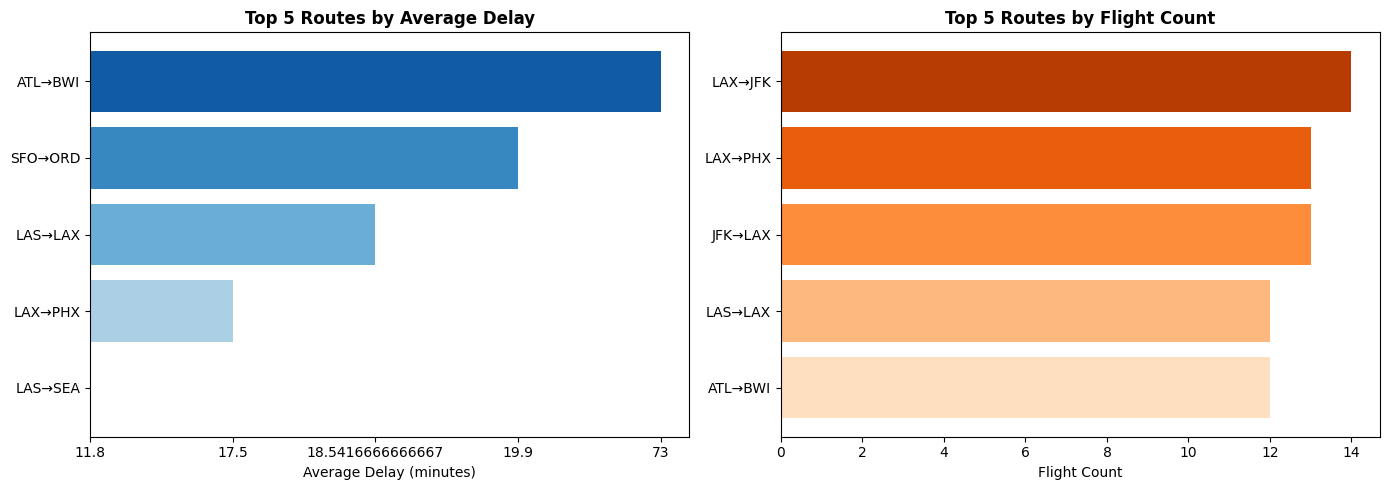

In [30]:
# plot degree and volume for top routes and airports
SIZE=5

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

vol_plot = top_routes_delay.head(SIZE).copy()
vol_plot["route"] = vol_plot["origin"] + "→" + vol_plot["destination"]
axes[0].barh(vol_plot["route"][::-1], vol_plot["avg_delay"][::-1], color=sns.color_palette("Blues", SIZE))
axes[0].set_title(f"Top {SIZE} Routes by Average Delay", fontweight="bold")
axes[0].set_xlabel("Average Delay (minutes)")

hub_plot = top_routes_count.head(SIZE).copy()
hub_plot["route"] = hub_plot["origin"] + "→" + hub_plot["destination"]
axes[1].barh(hub_plot["route"][::-1], hub_plot["flights"][::-1], color=sns.color_palette("Oranges", SIZE))
axes[1].set_title(f"Top {SIZE} Routes by Flight Count", fontweight="bold")
axes[1].set_xlabel("Flight Count")

plt.tight_layout()
plt.show()

# Hub airports via simple in/out degree

In [31]:
# find top hub airport
# the degree is computed as the sum of 
# incoming  edges
_graph_query_to_df(driver.execute_command("GRAPH.QUERY", DATABASE, """
MATCH (a:Airport)
OPTIONAL MATCH ()-[inn:ROUTE_TO]->(a)
WITH a, 
     count(inn) AS in_degree
RETURN a.iata AS iata,  in_degree
ORDER BY in_degree DESC
""")) .head()

,iata,in_degree
0,ATL,107
1,ORD,94
2,DFW,92
3,DEN,74
4,IAH,68


In [32]:
# find top hub airport
# the degree is computed as the sum of 
# outgoing  edges
airport_out_degree = _graph_query_to_df(driver.execute_command("GRAPH.QUERY", DATABASE, """
MATCH (a:Airport)
OPTIONAL MATCH (a)-[out:ROUTE_TO]->()
WITH a, 
     count(out) AS out_degree
RETURN a.iata AS iata,
       out_degree
ORDER BY out_degree DESC
"""))
airport_out_degree.head()

,iata,out_degree
0,ATL,108
1,ORD,96
2,DFW,87
3,DEN,80
4,IAH,66


### End of FASE 1

The graph is highly concentrated around a small number of hubs, which is consistent with the structure of the US domestic flight network. Route frequencies are also uneven, with a limited number of airport pairs carrying a large share of the traffic.

This suggests that disruption at a hub airport or on a heavily used route can affect many other nodes in the network. For this reason, centrality betww and community-based techniques are appropriate for the second phase of the analysis.

# Research question definition - FASE 2

- Cypher Projection Usage [Not supported by new Neo4j]

1. Do some airports act as cascade initiators whose delays propagate and disproportionately affect airports within the same operational clusters?
2. Are there specific routes whose disruption would severely disconnect groups of airports (i.e., bridges between communities)?
3. How does the network behave when critical inter-community links are removed?


# Q1


## Q1 Methodological Choice

To identify airports that may trigger delay propagation, the following methods are used:
- Louvain community detection to group airports into operational clusters.
- Weighted degree to measure how strongly an airport is connected to the rest of its community.
- Betweenness centrality to identify airports that sit on many important paths between airports.

These techniques are suitable because an airport that is both well connected and structurally central inside a community is more likely to amplify service disruptions, including delays.

In [33]:
#  Build projection for community and path analysis 
# not needed by falkordb, but can be used as a general check for GDS presence and version.

# Queries using create projection
communities = _graph_query_to_df(driver.execute_command("GRAPH.QUERY", DATABASE, """
CALL algo.labelPropagation({
    nodeLabels: ['Airport'],
    relationshipTypes: ['ROUTE_TO']
})
YIELD node, communityId
RETURN node.iata AS iata,
       node.state AS state,
       communityId
ORDER BY communityId, iata
"""))

deg_df = _graph_query_to_df(driver.execute_command("GRAPH.QUERY", DATABASE, """
MATCH (a:Airport)-[r:ROUTE_TO]->()
WHERE r.flights IS NOT NULL
WITH a, sum(r.flights) AS weighted_degree
RETURN a.iata AS iata,
       weighted_degree
ORDER BY weighted_degree DESC
"""))

btw_df = _graph_query_to_df(driver.execute_command("GRAPH.QUERY", DATABASE, """
CALL algo.betweenness({
    nodeLabels: ['Airport'],
    relationshipTypes: ['ROUTE_TO'],
    samplingSeed: 667
})
YIELD node, score
RETURN node.iata AS iata,
       score AS betweenness
ORDER BY score DESC
"""))

# avg total_delay per origin using Flight nodes and FROM relationship (matches your schema)
delay_df = _graph_query_to_df(driver.execute_command("GRAPH.QUERY", DATABASE, """
MATCH (f:Flight)-[rf:FROM]->(o:Airport)
WHERE f.total_delay IS NOT NULL AND o.iata IS NOT NULL
WITH o.iata AS iata, avg(f.total_delay) AS avgDelay
RETURN iata, avgDelay
"""))

# Merge and postprocess
df = communities.merge(deg_df, on='iata', how='left') \
                .merge(btw_df, on='iata', how='left') \
                .merge(delay_df, on='iata', how='left')

for c in ['weighted_degree','betweenness','avgDelay']:
    if c in df.columns:
        df[c] = df[c].fillna(0.0)

df['weighted_degree'] = pd.to_numeric(df['weighted_degree'], errors='coerce').fillna(0.0)
df['betweenness'] = pd.to_numeric(df['betweenness'], errors='coerce').fillna(0.0)
df['avgDelay'] = pd.to_numeric(df['avgDelay'], errors='coerce').fillna(0.0)

df['degree_rank'] = df['weighted_degree'].rank(method='dense', ascending=False).astype(int)

if 'avgDelay' in df.columns:
    lo = df['avgDelay'].min(); hi = df['avgDelay'].max()
    df['norm_avgDelay'] = (df['avgDelay'] - lo) / (hi - lo) if hi>lo else 0.0
else:
    df['norm_avgDelay'] = 0.0

df.sort_values(['communityId','degree_rank']).reset_index(drop=True)

,iata,state,communityId,weighted_degree,betweenness,avgDelay,degree_rank,norm_avgDelay
0,YAK,AK,1,0.0,0.0,0.0,63,0.000000
1,HIB,MN,2,1.0,0.0,0.0,62,0.000000
2,INL,MN,2,1.0,0.0,0.0,62,0.000000
3,MEI,MS,2,1.0,32.0,0.0,62,0.000000
4,WRG,AK,3,1.0,0.0,0.0,62,0.000000
...,...,...,...,...,...,...,...,...
272,SPS,TX,14,0.0,0.0,0.0,63,0.000000
273,TLH,FL,14,0.0,0.0,0.0,63,0.000000
274,TOL,OH,14,0.0,0.0,0.0,63,0.000000
275,PSG,AK,63,1.0,0.0,5.5,62,0.006811


In [66]:


## ensure columns exist
#for c in ['weighted_degree','betweenness','norm_avgDelay','avgDelay','communityId','iata']:
#    if c not in df.columns:
#        df[c] = 0.0

# normalize D and B globally to [0,1] (min-max). If constant, set 0.
def minmax_series(s):
    s = s.astype(float)
    lo = s.min(); hi = s.max()
    if hi>lo:
        return (s - lo) / (hi - lo)
    return pd.Series(0.0, index=s.index)

df['Dhat'] = minmax_series(df['weighted_degree'])
df['Bhat'] = minmax_series(df['betweenness'])
# P hat: prefer existing normalized avgDelay if present, else normalize avgDelay
if 'norm_avgDelay' in df.columns and df['norm_avgDelay'].notna().any():
    df['Phat'] = df['norm_avgDelay'].fillna(0.0)
else:
    df['Phat'] = minmax_series(df['avgDelay'])

# fragility
df['fragility'] =  (df['Bhat'] +  df['Dhat'] +  df['Phat']) / 3.0

# filter communities
SIZE = 1
comm_sizes = df.groupby('communityId').size().rename('size')
large_comms = comm_sizes[comm_sizes>SIZE].index.tolist()
df_large = df[df['communityId'].isin(large_comms)].copy()

# for each community, get top 2 by fragility
TOP_N = 6
top_per_comm = df_large.sort_values(['communityId','fragility'], ascending=[True, False]) \
                       .groupby('communityId').head(TOP_N) \
                       .reset_index(drop=True)

In [67]:
top_per_plot = top_per_comm[['iata',"communityId","fragility"]]
top_per_plot

,iata,communityId,fragility
0,MEI,2,0.010355
1,HIB,2,0.001026
2,INL,2,0.001026
3,ATL,14,0.674582
4,ORD,14,0.525636
5,DFW,14,0.481020
6,DEN,14,0.397056
7,ACK,14,0.334359
8,MSP,14,0.286078


/tmp/ipykernel_1081547/220782174.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='fragility', y='iata', data=sub, ax=ax, palette=palette)
/tmp/ipykernel_1081547/220782174.py:31: UserWarning: The palette list has more values (20) than needed (3), which may not be intended.
  sns.barplot(x='fragility', y='iata', data=sub, ax=ax, palette=palette)
/tmp/ipykernel_1081547/220782174.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='fragility', y='iata', data=sub, ax=ax, palette=palette)
/tmp/ipykernel_1081547/220782174.py:31: UserWarning: The palette list has more values (20) than needed (6), which may not be intended.
  sns.barplot(x='fragility', y='iata', data=sub, ax=ax, palette=p

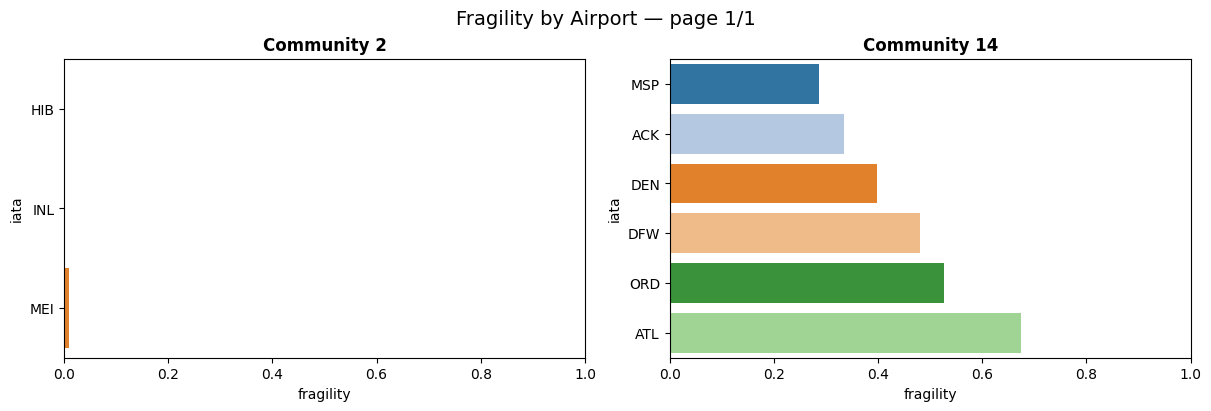

In [68]:
import math
import matplotlib.pyplot as plt
import seaborn as sns


per_page = 6         # subplot 
cols = 2
palette = sns.color_palette("tab20")

tp = top_per_plot.sort_values(['communityId', 'fragility'], ascending=[True, True])

comm_sizes = tp.groupby('communityId').size()
comms = comm_sizes.index.tolist()

pages = math.ceil(len(comms) / per_page)
for p in range(pages):
    page_comms = comms[p*per_page:(p+1)*per_page]
    k = len(page_comms)
    rows = math.ceil(k / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4*rows), constrained_layout=True, squeeze=False)
    axes = axes.ravel()
    if k == 0:
        plt.close(fig)
        continue
    # nascondo assi extra
    for ax in axes[k:]:
        ax.set_visible(False)
    for i, comm in enumerate(page_comms):
        ax = axes[i]
        sub = tp[tp['communityId'] == comm].sort_values('fragility', ascending=True)
        sns.barplot(x='fragility', y='iata', data=sub, ax=ax, palette=palette)
        ax.set_title(f"Community {comm}", fontweight='bold')
        ax.set_xlabel('fragility')
        ax.set_xlim(0, 1)           # fragility normalizzata in [0,1]
    fig.suptitle(f"Fragility by Airport — page {p+1}/{pages}", fontsize=14)
    plt.show()

## Q1 A1

ORD, ATL, and DFW show significantly higher fragility than their community peers, making them the best candidates to generate delay propagation within their respective clusters.


# Q2 



To study bridge-like routes, we focusing on routes connecting airports that are already highlighted as structurally fragile within their communities.

The purpose is to identify airport pairs that not only have high traffic, but also connect important local hubs across the network. 
These links are relevant because their disruption can reduce inter-community connectivity and isolate parts of the system more than a local route failure would.

In [69]:
# found critical route between critical airports

critical_iatas = top_per_plot["iata"].tolist()
iata_to_community = dict(zip(top_per_plot["iata"], top_per_plot["communityId"]))
main_community = set(top_per_plot["communityId"].tolist())

# Build Cypher-safe literals (no JSON syntax inside GRAPH.QUERY)
critical_iatas_cypher = "[" + ", ".join(cypher_value(iata) for iata in critical_iatas) + "]"

community_pairs = []
for iata, community_id in iata_to_community.items():
    safe_key = str(iata).replace("`", "")
    safe_val = "null" if pd.isna(community_id) else str(int(community_id))
    community_pairs.append(f"{safe_key}: {safe_val}")

iata_to_community_cypher = "{" + ", ".join(community_pairs) + "}"

main_community_routes = _graph_query_to_df(driver.execute_command(
    "GRAPH.QUERY",
    DATABASE,
    f"""
WITH {critical_iatas_cypher} AS critical_iatas, {iata_to_community_cypher} AS iata_to_community
MATCH (o:Airport)-[r:ROUTE_TO]->(d:Airport)
WHERE o.iata IN critical_iatas
  AND d.iata IN critical_iatas
  AND o.iata <> d.iata
RETURN o.iata AS origin,
       iata_to_community[o.iata] AS originCommunityId,
       d.iata AS dest,
       iata_to_community[d.iata] AS destCommunityId,
       r.flights AS flights,
       r.avg_delay AS avg_delay,
       r.total_delay AS total_delay
ORDER BY flights DESC, total_delay DESC, origin, dest
"""
))

main_community_routes

,origin,originCommunityId,dest,destCommunityId,flights,avg_delay,total_delay
0,DFW,14,ATL,14,8,7.375,59
1,MSP,14,ORD,14,8,0.75,6
2,ATL,14,DEN,14,7,118.571428571429,830
3,DFW,14,ORD,14,7,20.1428571428571,141
4,ATL,14,ORD,14,7,5.07142857142857,35.5
5,ATL,14,DFW,14,7,1.5,10.5
6,ORD,14,ATL,14,6,12.75,76.5
7,MSP,14,ATL,14,6,1.91666666666667,11.5
8,ORD,14,DFW,14,6,1.16666666666667,7
9,MSP,14,DFW,14,5,21.1,105.5


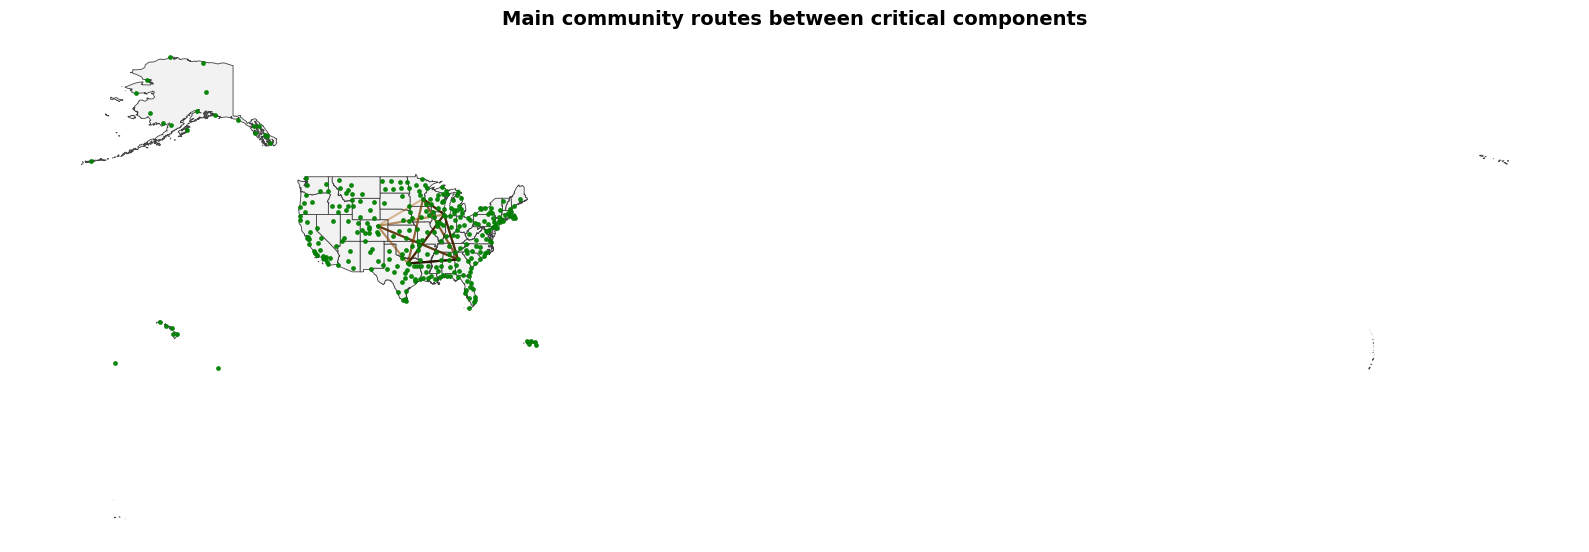

In [70]:
%reload_ext autoreload

from statlib.domain_tools import plot_main_community_routes_map 
routes_graph = plot_main_community_routes_map(
    main_community_routes=main_community_routes,
    title="Main community routes between critical components",
    airport_color='green',
    figsize=(16, 10),
    tmpdir=tmpdir,
    dfs_kv=dfs_kv,
    red_intensity=0.9
)

# Q2 A2

ORD is the strongest bridge in the network, because it repeatedly connects different main communities critical inter-community routes. DFW, ATL, and DEN also act as important connectors, while pairs such as JFK-LAX and ORD-SFO highlight the main long-range bridges between clusters. In practice, disrupting these routes would not isolate a single community only, but would reduce connectivity between multiple operational clusters at once.

# Q3

To study how the network behaves when critical inter-community links are removed, a weighted shortest-path analysis is used on the route graph.
The route network is represented as a directed graph where each edge weight is the average distance between two airports.

This choice is appropriate because the research question is not only about reachability, but also about how route removal changes the cost of moving through the network. 
Computing the shortest path before and after removing the selected critical routes makes it possible to quantify the impact of disruption in terms of path length and route efficiency.


In [71]:
# minimize miles

edges = _graph_query_to_df(driver.execute_command("GRAPH.QUERY", DATABASE, """
MATCH (o:Airport)-[r:ROUTE_TO]->(d:Airport)
RETURN o.iata AS source, d.iata AS target, r.avg_distance AS weight
"""))

G_weighted = nx.DiGraph()
for _, row in edges.iterrows():
    weight = float(row["weight"])
    G_weighted.add_edge(row["source"], row["target"], weight=weight)

low_rank_airport = _graph_query_to_df(driver.execute_command("GRAPH.QUERY", DATABASE, """
MATCH (a:Airport)
OPTIONAL MATCH (a)-[r:ROUTE_TO]->()
WITH a, count(r) AS degree
WHERE degree > 0 AND degree < 10  // Low degree airport
RETURN a.iata AS airport, degree
ORDER BY degree ASC
LIMIT 1
"""))
source_airport = low_rank_airport.iloc[0]['airport']
print(f"Selected low-rank airport: {source_airport}")

# not directly connected
destination_airport = _graph_query_to_df(driver.execute_command("GRAPH.QUERY", DATABASE, f"""
MATCH (source:Airport {{iata: '{source_airport}'}})
MATCH (dest:Airport)
WHERE source.iata <> dest.iata
OPTIONAL MATCH (source)-[r:ROUTE_TO]->(dest)
WITH dest, r
WHERE r IS NULL
RETURN dest.iata AS airport, dest.city AS city
LIMIT 1
"""))
destination_airport = destination_airport.iloc[0]['airport']
connected_path = nx.dijkstra_path(G_weighted, source_airport, destination_airport, weight='weight')
path_length = nx.dijkstra_path_length(G_weighted, source_airport, destination_airport, weight='weight')
print(f"Connected path: {connected_path}")
print(f"Path length: {path_length}")

critical_routes = main_community_routes[["origin","dest"]].values.tolist()
critical_routes = [(row[0], row[1]) for row in critical_routes]

G_pruned = nx.DiGraph()

for _, row in edges.iterrows():
    edge = (row["source"], row["target"])
    if edge not in critical_routes:
        try:
            weight = float(row["weight"])
            G_pruned.add_edge(row["source"], row["target"], weight=weight)
        except (ValueError, TypeError):
            print("Missing weight for edge:", edge)
            G_pruned.add_edge(row["source"], row["target"], weight=float('inf'))

connected_path = nx.dijkstra_path(G_pruned, source_airport, destination_airport, weight='weight')
path_length = nx.dijkstra_path_length(G_pruned, source_airport, destination_airport, weight='weight')
print(f"Connected path pruned: {connected_path}")
print(f"Path length pruned: {path_length}")


Selected low-rank airport: HPN
Connected path: ['HPN', 'ATL', 'PHX', 'YUM']
Path length: 2527.0
Connected path pruned: ['HPN', 'ATL', 'PHX', 'YUM']
Path length pruned: 2527.0


# Q3 A3


After removing the selected critical inter-community links, the network still finds an alternative path between the chosen airports, but the path becomes longer and less direct.

This indicates that the network has some redundancy, but not enough to ignore the role of bridge routes. The result suggests partial resilience rather than guaranteed robustness, because the effect depends on the specific source, destination, and removed edges.

# Conclusion

The graph analysis shows that the US flight network is organized around a small number of highly central airports and route corridors. Community detection and centrality measures help identify airports that are likely to amplify delay propagation, while shortest-path analysis shows that the network has some redundancy but still depends on critical inter-community links.
